# Kaggle Text Polarity Classification - Exploratory Data Analysis (EDA)

這份 Notebook 將協助您在 `textpolarity` 環境下進行文本情感分類的視覺化資料探索。
首先，我們先確認已經生成了 `requirements.txt` 並準備好資料集。

In [9]:
!pip install -r ../requirements.txt

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 設定視覺化風格
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries loaded successfully.")

Required libraries loaded successfully.


In [11]:
# 載入資料集
train_df = pd.read_csv('../datasets/train_2022.csv')
test_df = pd.read_csv('../datasets/test_2022.csv')

print(f"訓練集 (Train) 大小: {train_df.shape}")
print(f"測試集 (Test) 大小:  {test_df.shape}")

print("\n--- 訓練集前五筆 ---")
display(train_df.head())

print("\n--- 檢查缺失值 ---")
print("Train missing:")
display(train_df.isnull().sum())
print("\nTest missing:")
display(test_df.isnull().sum())

訓練集 (Train) 大小: (2000, 3)
測試集 (Test) 大小:  (11000, 2)

--- 訓練集前五筆 ---


,row_id,TEXT,LABEL
0,0,director dirk shafer and co-writer greg hinton...,0
1,1,"a charming , quirky and leisurely paced scotti...",1
2,2,"the price was good , and came quickly though ...",1
3,3,i was looking forward to this game for a coupl...,0
4,4,arguably the year 's silliest and most incoher...,0



--- 檢查缺失值 ---
Train missing:


row_id    0
TEXT      0
LABEL     0
dtype: int64


Test missing:


row_id    0
TEXT      0
dtype: int64

/tmp/ipykernel_18335/2507912331.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='LABEL', ax=ax, palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_18335/2507912331.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Negative (0)', 'Positive (1)'])


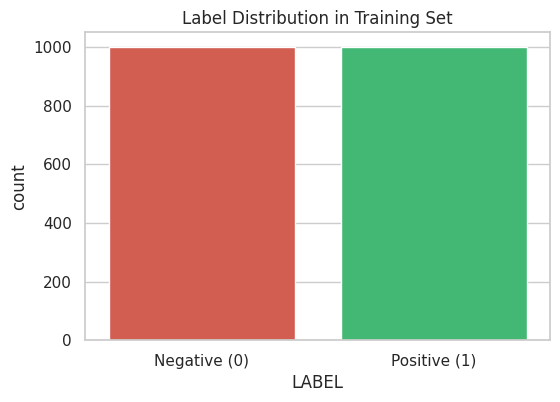

LABEL distribution counts:
LABEL
0    1000
1    1000
Name: count, dtype: int64


In [12]:
# 標籤分佈 - Train Dataset
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train_df, x='LABEL', ax=ax, palette=['#e74c3c', '#2ecc71'])
ax.set_title("Label Distribution in Training Set")
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
plt.show()

print("LABEL distribution counts:")
print(train_df['LABEL'].value_counts())

/tmp/ipykernel_18335/928676667.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df['word_count'], shade=True, color='blue', label='Train Word Count', ax=axes[0])
/tmp/ipykernel_18335/928676667.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_df['word_count'], shade=True, color='red', label='Test Word Count', ax=axes[0])
/tmp/ipykernel_18335/928676667.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df['text_len'], shade=True, color='blue', label='Train Text Length', ax=axes[1])
/tmp/ipykernel_18335/928676667.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=T

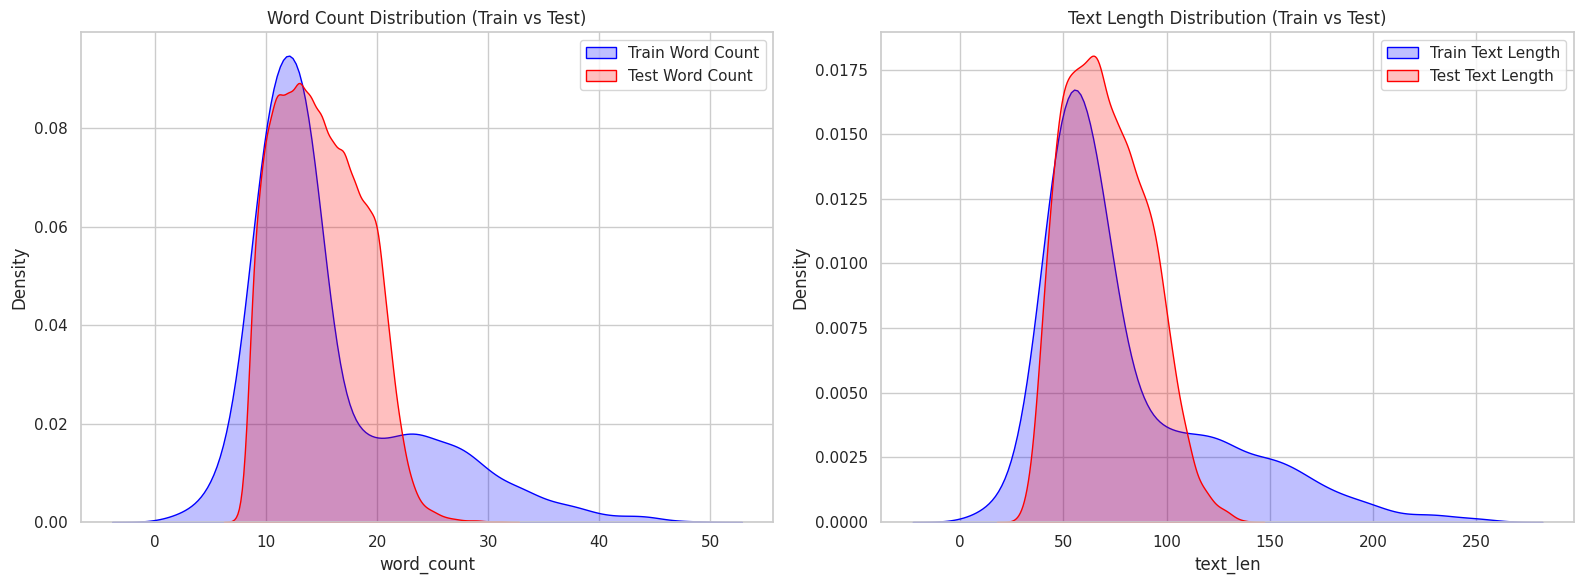

In [13]:
# 計算文本長度與單詞數
train_df['text_len'] = train_df['TEXT'].astype(str).str.len()
train_df['word_count'] = train_df['TEXT'].astype(str).apply(lambda x: len(x.split()))

test_df['text_len'] = test_df['TEXT'].astype(str).str.len()
test_df['word_count'] = test_df['TEXT'].astype(str).apply(lambda x: len(x.split()))

# 繪製 Train 與 Test 的長度與單詞數對比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(train_df['word_count'], shade=True, color='blue', label='Train Word Count', ax=axes[0])
sns.kdeplot(test_df['word_count'], shade=True, color='red', label='Test Word Count', ax=axes[0])
axes[0].set_title('Word Count Distribution (Train vs Test)')
axes[0].legend()

sns.kdeplot(train_df['text_len'], shade=True, color='blue', label='Train Text Length', ax=axes[1])
sns.kdeplot(test_df['text_len'], shade=True, color='red', label='Test Text Length', ax=axes[1])
axes[1].set_title('Text Length Distribution (Train vs Test)')
axes[1].legend()

plt.tight_layout()
plt.show()

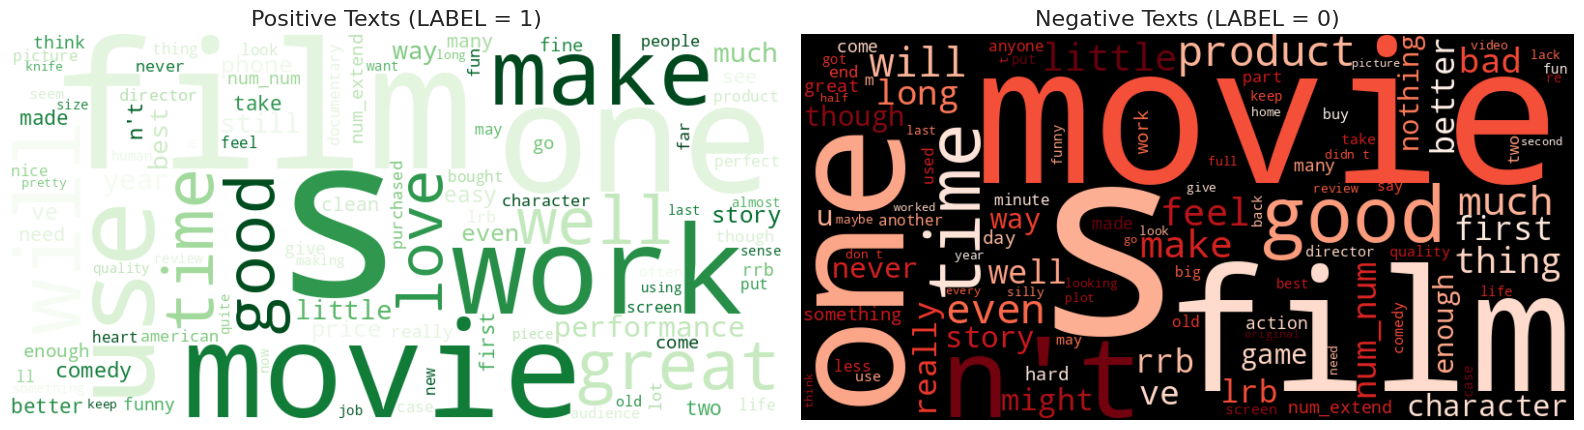

In [14]:
# 按照極性 (Label) 拆分文字來做 WordClouds
text_pos = " ".join(train_df[train_df['LABEL'] == 1]['TEXT'].astype(str))
text_neg = " ".join(train_df[train_df['LABEL'] == 0]['TEXT'].astype(str))

# 建立 Positive WordCloud
wordcloud_pos = WordCloud(width=800, height=400, max_words=100,
                          background_color="white", colormap="Greens").generate(text_pos)

# 建立 Negative WordCloud
wordcloud_neg = WordCloud(width=800, height=400, max_words=100,
                          background_color="black", colormap="Reds").generate(text_neg)

# 畫圖
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wordcloud_pos, interpolation="bilinear")
axes[0].set_title("Positive Texts (LABEL = 1)", fontsize=16)
axes[0].axis("off")

axes[1].imshow(wordcloud_neg, interpolation="bilinear")
axes[1].set_title("Negative Texts (LABEL = 0)", fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()